LAB01 - Tarefa 04

Para esta próxima atividade baixar o arquivo cliente.csv disponibilizado na nossa Comunidade da disciplina no MCOnf©. Podemos utilizar esta base de dados para analisar um pedido de empréstimo. Considerar que a renda (income) e a pontuação de crédito são as características (score) e a variável padrão (default) é o rótulo, ou seja, temos uma base supervisionada (rótulo = NO = cliente terá seu pedido de empréstimo negado e YES terá seu pedido de empréstimo aceito). Para esta análise baixar o arquivo Lab01Tarefa04 disponibilizado na nossa Comunidade da disciplina no Moodle©. Abrir o ambiente de programação Python, utilizar o código disponibilizado no arquivo e analisar o mesmo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Carrega minha pasta do GoogleDrive onde está localizada a base de dados
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dados=pd.read_csv('/content/drive/MyDrive/Python/IA_Para_Engenheiros/Algoritmos_Para_Agrupamento_De_Dados/Dados - Especialização/cliente.csv')
dados

,Name,income,score,default
0,0,78479,800,NO
1,1,95483,801,NO
2,2,101641,815,NO
3,3,104234,790,NO
4,4,108726,795,NO
5,5,112845,750,NO
6,6,114114,799,NO
7,7,114799,801,NO
8,8,119147,805,NO
9,9,119976,790,NO


In [4]:
dados.drop(columns = ['Name'],inplace=True)
dados

,income,score,default
0,78479,800,NO
1,95483,801,NO
2,101641,815,NO
3,104234,790,NO
4,108726,795,NO
5,112845,750,NO
6,114114,799,NO
7,114799,801,NO
8,119147,805,NO
9,119976,790,NO


In [5]:
novoDado = dados.iloc[20]
novoDado

,20
income,98487
score,785
default,NaN


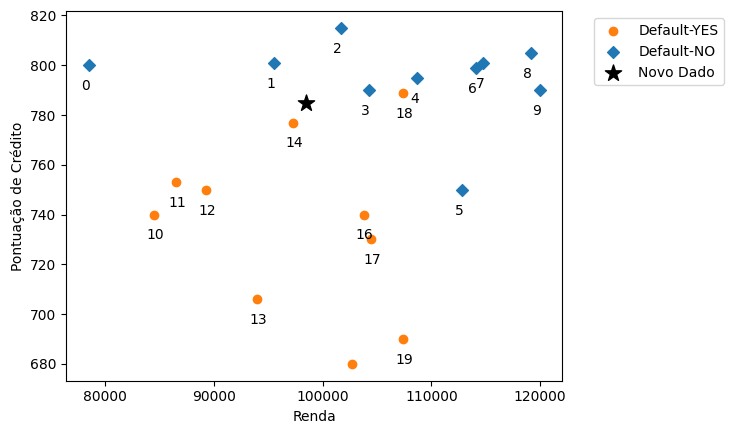

In [6]:
dados=pd.read_csv('/content/drive/MyDrive/Python/IA_Para_Engenheiros/Algoritmos_Para_Agrupamento_De_Dados/Dados - Especialização/cliente.csv')
dados.drop(index = [20],inplace=True)
fig, ax = plt.subplots()
subconjunto = dados.loc[dados['default']=='Yes']
ax.scatter(subconjunto.income, subconjunto.score, marker='o', label='Default-YES', color='C1')
subconjunto = dados.loc[dados['default']=='NO']
ax.scatter(subconjunto.income, subconjunto.score, marker='D', label='Default-NO', color='C0')
ax.scatter(novoDado.income, novoDado.score, marker='*', label='Novo Dado', color='black', s=150)
plt.xlabel('Renda')
plt.ylabel('Pontuação de Crédito')
for _, x in dados.iterrows():
    ax.annotate(x.Name, (x.income -700, x.score-10))
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1))
plt.show()

In [7]:
# normalizei no "braço" os dados
dados = pd.read_csv('/content/drive/MyDrive/Python/IA_Para_Engenheiros/Algoritmos_Para_Agrupamento_De_Dados/Dados - Especialização/cliente.csv')
dados['income_Normalizado'] = (dados.income - dados.income.min())/(dados.income.max() - dados.income.min())
dados['score_Normalizado'] = (dados.score - dados.score.min())/(dados.score.max() - dados.score.min())

In [8]:
dados.drop(columns = ['Name'])

,income,score,default,income_Normalizado,score_Normalizado
0,78479,800,NO,0.000000,0.888889
1,95483,801,NO,0.409765,0.896296
2,101641,815,NO,0.558161,1.000000
3,104234,790,NO,0.620647,0.814815
4,108726,795,NO,0.728896,0.851852
5,112845,750,NO,0.828156,0.518519
6,114114,799,NO,0.858737,0.881481
7,114799,801,NO,0.875244,0.896296
8,119147,805,NO,0.980023,0.925926
9,119976,790,NO,1.000000,0.814815


In [9]:
# execução do k-NN - usei k = 4 em casa avaliar se é a melhor escolha para o k

from sklearn.neighbors import KNeighborsClassifier
preditor = ['income_Normalizado','score_Normalizado']
alvo = 'default'
Xs = dados[preditor].drop(index=[20])
y= dados[alvo].drop(index=[20])
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(Xs, y)
novoDado = pd.DataFrame({'income_Normalizado': dados.iloc[20].income_Normalizado,
                         'score_Normalizado': dados.iloc[20].score_Normalizado},index = [20])
predito_y = knn.predict(novoDado)
print(predito_y)

['NO']


Pergunta importante: receberá ou não crédito?